<a href="https://colab.research.google.com/github/Maxieee3/lorenzo-philippines-market-analysis/blob/main/notebooks/01_philippine_automotive_market_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/Maxieee3/lorenzo-philippines-market-analysis/main/data/raw/philippines_vehicle_sales_2025.csv"

vehicle_sales = pd.read_csv(url)

vehicle_sales

,manufacturer,sales_2025
0,Toyota,229447
1,Mitsubishi,86808
2,Suzuki,21984
3,Ford,21784
4,Nissan,20571
5,Honda,16257
6,Hyundai,10475
7,Tesla,2424
8,Mazda,1633
9,BMW,950


In [2]:
vehicle_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   manufacturer  13 non-null     object
 1   sales_2025    13 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 340.0+ bytes


In [3]:
vehicle_sales.isnull().sum()

,0
manufacturer,0
sales_2025,0


In [4]:
total_market_sales_2025 = 491395

vehicle_sales["market_share_percent"] = (
    vehicle_sales["sales_2025"] / total_market_sales_2025 * 100
)

vehicle_sales["market_share_percent"] = vehicle_sales["market_share_percent"].round(2)

vehicle_sales.sort_values("sales_2025", ascending=False)

,manufacturer,sales_2025,market_share_percent
0,Toyota,229447,46.69
1,Mitsubishi,86808,17.67
2,Suzuki,21984,4.47
3,Ford,21784,4.43
4,Nissan,20571,4.19
5,Honda,16257,3.31
6,Hyundai,10475,2.13
7,Tesla,2424,0.49
8,Mazda,1633,0.33
9,BMW,950,0.19


In [5]:
premium_brands = [
    "Tesla",
    "Mazda",
    "BMW",
    "Mercedes-Benz",
    "Jaguar Land Rover",
    "Ferrari"
]

premium_sales = vehicle_sales[
    vehicle_sales["manufacturer"].isin(premium_brands)
].copy()

premium_sales.sort_values("sales_2025", ascending=False)

,manufacturer,sales_2025,market_share_percent
7,Tesla,2424,0.49
8,Mazda,1633,0.33
9,BMW,950,0.19
10,Mercedes-Benz,563,0.11
11,Jaguar Land Rover,202,0.04
12,Ferrari,32,0.01


In [6]:
lorenzo_scenarios = pd.DataFrame({
    "scenario": [
        "Conservative",
        "Base",
        "Growth",
        "Aggressive"
    ],
    "lorenzo_sales": [
        250,
        500,
        1000,
        2000
    ]
})

lorenzo_scenarios["market_share_percent"] = (
    lorenzo_scenarios["lorenzo_sales"] / total_market_sales_2025 * 100
).round(2)

lorenzo_scenarios

,scenario,lorenzo_sales,market_share_percent
0,Conservative,250,0.05
1,Base,500,0.10
2,Growth,1000,0.20
3,Aggressive,2000,0.41


In [7]:
competitor_comparison = premium_sales[
    ["manufacturer", "sales_2025"]
].copy()

competitor_comparison.columns = ["name", "annual_sales"]
competitor_comparison["type"] = "Existing Brand"

lorenzo_comparison = lorenzo_scenarios[
    ["scenario", "lorenzo_sales"]
].copy()

lorenzo_comparison["scenario"] = "Lorenzo - " + lorenzo_comparison["scenario"]
lorenzo_comparison.columns = ["name", "annual_sales"]
lorenzo_comparison["type"] = "Lorenzo Scenario"

comparison = pd.concat(
    [competitor_comparison, lorenzo_comparison],
    ignore_index=True
)

comparison = comparison.sort_values(
    "annual_sales",
    ascending=False
)

comparison

,name,annual_sales,type
0,Tesla,2424,Existing Brand
9,Lorenzo - Aggressive,2000,Lorenzo Scenario
1,Mazda,1633,Existing Brand
8,Lorenzo - Growth,1000,Lorenzo Scenario
2,BMW,950,Existing Brand
3,Mercedes-Benz,563,Existing Brand
7,Lorenzo - Base,500,Lorenzo Scenario
6,Lorenzo - Conservative,250,Lorenzo Scenario
4,Jaguar Land Rover,202,Existing Brand
5,Ferrari,32,Existing Brand


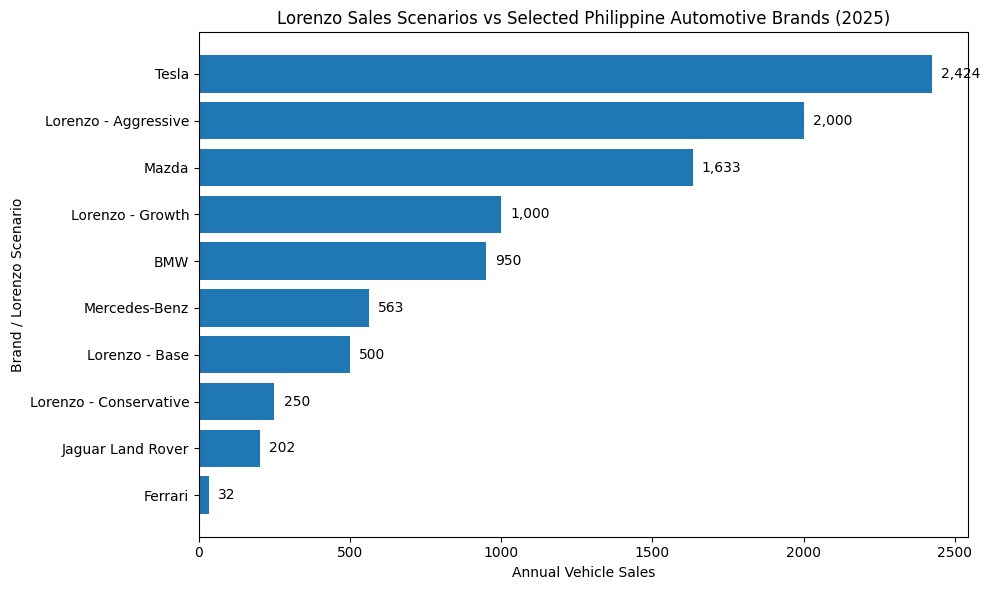

In [8]:
import matplotlib.pyplot as plt

chart_data = comparison.sort_values(
    "annual_sales",
    ascending=True
)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    chart_data["name"],
    chart_data["annual_sales"]
)

plt.xlabel("Annual Vehicle Sales")
plt.ylabel("Brand / Lorenzo Scenario")
plt.title("Lorenzo Sales Scenarios vs Selected Philippine Automotive Brands (2025)")

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 30,
        bar.get_y() + bar.get_height() / 2,
        f"{int(width):,}",
        va="center"
    )

plt.tight_layout()
plt.show()

In [9]:
lorenzo_financial_scenarios = pd.DataFrame({
    "scenario": [
        "Conservative",
        "Base",
        "Growth",
        "Aggressive"
    ],
    "annual_sales": [
        250,
        500,
        1000,
        2000
    ]
})

# Initial assumptions - we will refine these later with real data
average_selling_price = 5_000_000      # PHP per vehicle
manufacturing_cost_per_car = 3_500_000 # PHP per vehicle
annual_fixed_costs = 750_000_000       # PHP per year

gross_profit_per_car = (
    average_selling_price - manufacturing_cost_per_car
)

lorenzo_financial_scenarios["revenue_php"] = (
    lorenzo_financial_scenarios["annual_sales"] *
    average_selling_price
)

lorenzo_financial_scenarios["gross_profit_php"] = (
    lorenzo_financial_scenarios["annual_sales"] *
    gross_profit_per_car
)

lorenzo_financial_scenarios["operating_profit_php"] = (
    lorenzo_financial_scenarios["gross_profit_php"] -
    annual_fixed_costs
)

lorenzo_financial_scenarios

,scenario,annual_sales,revenue_php,gross_profit_php,operating_profit_php
0,Conservative,250,1250000000,375000000,-375000000
1,Base,500,2500000000,750000000,0
2,Growth,1000,5000000000,1500000000,750000000
3,Aggressive,2000,10000000000,3000000000,2250000000


In [11]:
import math

break_even_units = math.ceil(
    annual_fixed_costs / gross_profit_per_car
)

gross_margin_percent = (
    gross_profit_per_car / average_selling_price * 100
)

print(f"Average selling price: ₱{average_selling_price:,.0f}")
print(f"Manufacturing cost per vehicle: ₱{manufacturing_cost_per_car:,.0f}")
print(f"Gross profit per vehicle: ₱{gross_profit_per_car:,.0f}")
print(f"Gross margin: {gross_margin_percent:.1f}%")
print(f"Annual fixed costs: ₱{annual_fixed_costs:,.0f}")
print(f"Break-even sales volume: {break_even_units:,} vehicles per year")

Average selling price: ₱5,000,000
Manufacturing cost per vehicle: ₱3,500,000
Gross profit per vehicle: ₱1,500,000
Gross margin: 30.0%
Annual fixed costs: ₱750,000,000
Break-even sales volume: 500 vehicles per year
